<a href="https://colab.research.google.com/github/AadityaBhure/Deep-Learning-Lab---7th-Semester/blob/main/prac11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

In [2]:
# Load MNIST directly from Keras
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape : (10000, 28, 28)


In [3]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape : (10000, 28, 28, 1)


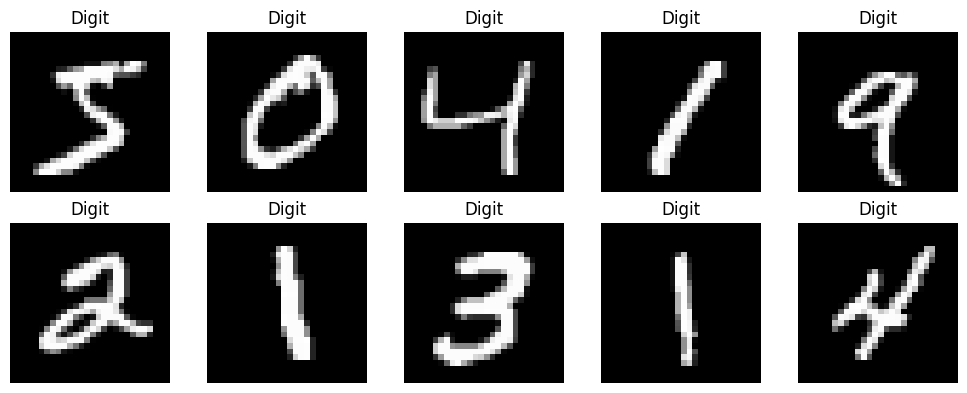

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Digit")

plt.tight_layout()
plt.show()

In [5]:
encoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # 28x28x1 -> 14x14x32
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    # 14x14x32 -> 7x7x16
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same")
])

encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,944 (19.31 KB)

 Trainable params: 4,944 (19.31 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
decoder = models.Sequential([
    layers.Input(shape=(7, 7, 16)),

    # 7x7x16 -> 14x14x16
    layers.Conv2DTranspose(
        16, (3, 3),
        strides=2,
        activation="relu",
        padding="same"
    ),

    # 14x14x16 -> 28x28x32
    layers.Conv2DTranspose(
        32, (3, 3),
        strides=2,
        activation="relu",
        padding="same"
    ),

    # Reconstruct original image
    layers.Conv2D(
        1, (3, 3),
        activation="sigmoid",
        padding="same"
    )
])

decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,249 (28.32 KB)

 Trainable params: 7,249 (28.32 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
autoencoder = models.Sequential([
    encoder,
    decoder
])

autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 7, 7, 16)       │         4,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │         7,249 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

print("Model compiled successfully!")

Model compiled successfully!


In [9]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 243ms/step - loss: 0.1557 - val_loss: 0.0794
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 242ms/step - loss: 0.0765 - val_loss: 0.0732
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.0728 - val_loss: 0.0712
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.0712 - val_loss: 0.0700
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 237ms/step - loss: 0.0703 - val_loss: 0.0693
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 234ms/step - loss: 0.0696 - val_loss: 0.0688
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 235ms/step - loss: 0.0690 - val_loss: 0.0682
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 234ms/step - loss: 0.0686 - val_loss: 0.0679
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 234ms/step - loss: 0.0682 - val_loss: 0.0675
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 251ms/step - loss: 0.0679 - val_loss: 0.0672


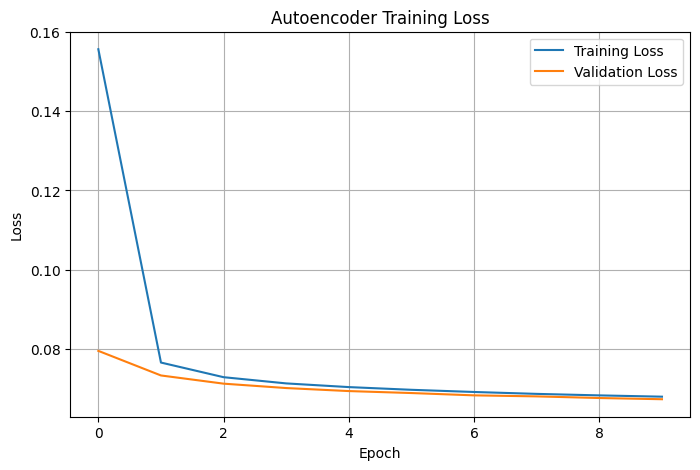

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid()

plt.show()

In [11]:
reconstructed = autoencoder.predict(x_test)

print("Original shape     :", x_test.shape)
print("Reconstructed shape:", reconstructed.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
Original shape     : (10000, 28, 28, 1)
Reconstructed shape: (10000, 28, 28, 1)


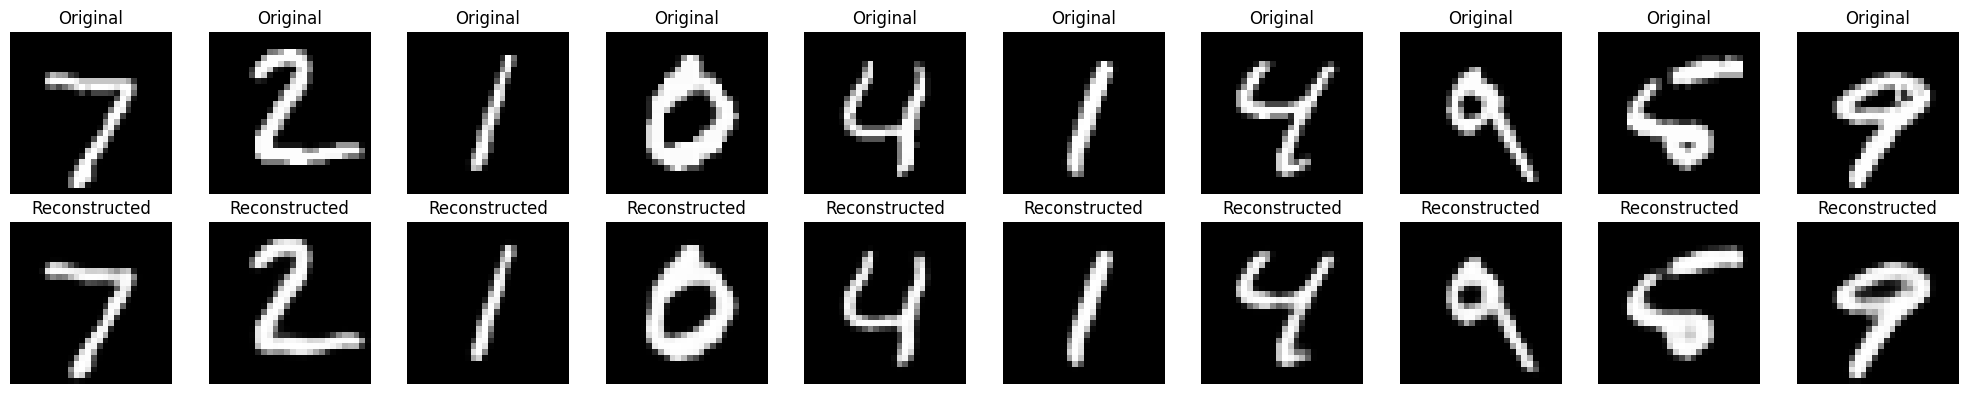

In [12]:
n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
mse = np.mean((x_test - reconstructed) ** 2)

print("Mean Squared Reconstruction Error:", mse)

Mean Squared Reconstruction Error: 0.0023745887
